# Stage 1 — Local Train

Train a YOLO model to detect license plates. The goal is a working training
pipeline, not accuracy.

## Environment

In [15]:
import sys
from pathlib import Path

import torch
import ultralytics

# Repo root, so paths do not depend on the notebook's working directory.
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

print("python     ", sys.version.split()[0])
print("torch      ", torch.__version__)
print("ultralytics", ultralytics.__version__)
print("cuda       ", torch.cuda.is_available())

python      3.12.10
torch       2.13.0+cpu
ultralytics 8.4.116
cuda        False


## Data summary

Inspect the raw dataset before training. Ultralytics accepts a mismatched
directory without complaint, so orphans and malformed labels have to be
caught here.

In [16]:
from src.data_loader import summarize

stats = summarize(RAW)
for key, value in stats.items():
    print(f"{key:22} {value}")

pairs                  556
orphan_images          []
orphan_labels          []
boxes_total            574
boxes_per_image_min    1
boxes_per_image_max    3
boxes_per_image_mean   1.03
images_without_boxes   0
class_counts           {'0': 574}
suffixes               {'.jpeg': 543, '.png': 13}
malformed              []


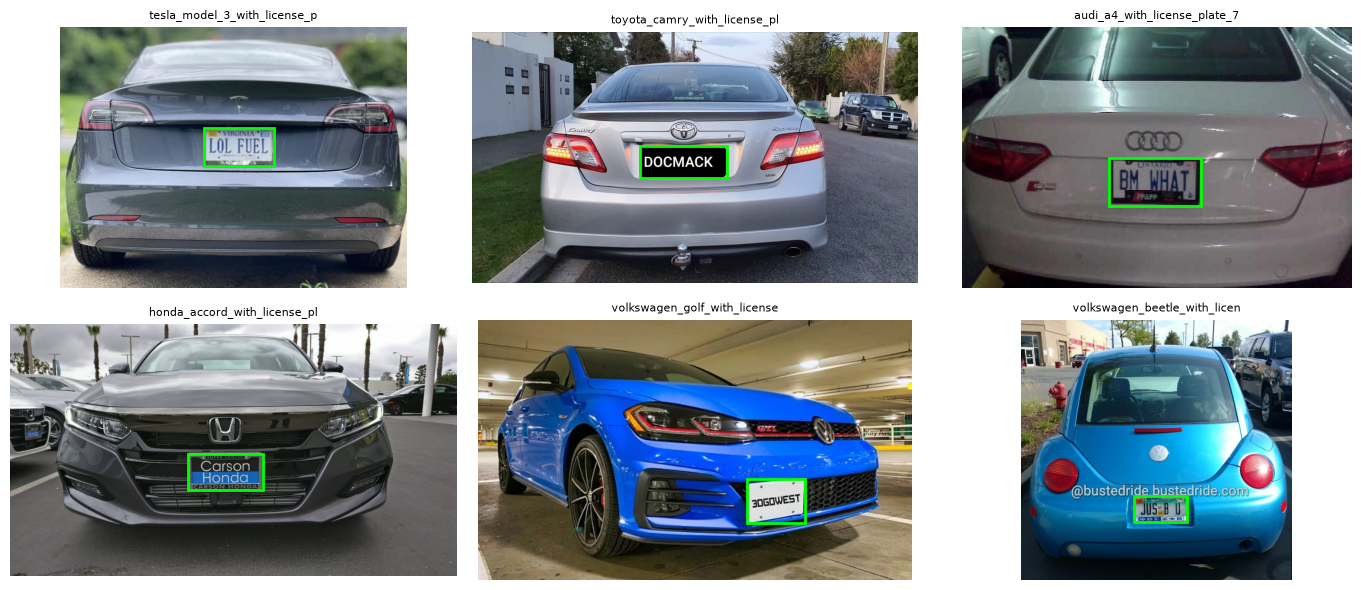

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

from src.data_loader import find_pairs


def show_sample(pairs, n=6, seed=0):
    """Draw label boxes on a few images to confirm the annotations line up."""
    import random

    sample = random.Random(seed).sample(pairs, n)
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    for ax, (img_path, lbl_path) in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        ax.imshow(img)
        w, h = img.size
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            # YOLO stores normalised centre + size; matplotlib wants corners.
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h),
                    bw * w,
                    bh * h,
                    fill=False,
                    edgecolor="lime",
                    linewidth=2,
                )
            )
        ax.set_title(img_path.stem[:28], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


pairs, _, _ = find_pairs(RAW)
show_sample(pairs)

## Split

80/20 train/val, seeded so the split is reproducible. `LIMIT` caps the number
of pairs — training is CPU-only here, so start small and raise it once the
pipeline runs end to end.

In [18]:
from src.data_loader import build_split, verify_split

LIMIT = None  # e.g. 200 for a fast smoke run; None uses all pairs

print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=0))
print(verify_split(PROCESSED))

{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}


## Dataset descriptor

Single class, read from `classes.txt`.

In [19]:
from src.data_loader import write_data_yaml

names = (RAW / "classes.txt").read_text().split()
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)

print(data_yaml)
print(data_yaml.read_text())

c:\Users\simon\OneDrive\Tech\Github\kubeflow-yolo\configs\data.yaml
path: c:/Users/simon/OneDrive/Tech/Github/kubeflow-yolo/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Model

`yolo11n` — the smallest variant, which matters on CPU. Loading pretrained
weights rather than training from scratch: 445 images is far too few to learn
features from nothing.

In [20]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

# Confirm the descriptor resolves and both splits are found before training.
from ultralytics.data.utils import check_det_dataset

checked = check_det_dataset(str(data_yaml))
print({k: checked[k] for k in ("nc", "names", "train", "val")})

{'nc': 1, 'names': {0: 'car_plate'}, 'train': 'C:\\Users\\simon\\OneDrive\\Tech\\Github\\kubeflow-yolo\\data\\processed\\train\\images', 'val': 'C:\\Users\\simon\\OneDrive\\Tech\\Github\\kubeflow-yolo\\data\\processed\\val\\images'}


### Training hyperparameters

Kept in `configs/train.yaml` rather than hardcoded. Small `imgsz` and `epochs`
because this runs on CPU.

In [21]:
import yaml

train_cfg = yaml.safe_load((ROOT / "configs" / "train.yaml").read_text())
train_cfg

{'model': 'yolo11n.pt',
 'epochs': 10,
 'imgsz': 416,
 'batch': 8,
 'device': 'cpu',
 'workers': 4,
 'seed': 0,
 'project': 'runs',
 'name': 'local-train',
 'exist_ok': True}